In [ ]:
!pip install scanpy==1.9.3 anndata==0.8.0
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install harmonypy
!pip install scvi-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 82.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
# import anndata as ad

data_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Baron_Pancreas_Human_mix.h5ad"


In [ ]:
# read adata
adata = sc.read_h5ad(data_path)

In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'


In [ ]:

adata.var.head()

""
A1BG
A1CF
A2M
A2ML1
A4GALT


In [ ]:
adata.obs.head()

,donor_id,cell_type,barcode,donor_batch
Cell_id,,,,
human1_lib1.final_cell_0001,human1,acinar,GATGACGGAC-GGTGGGAT,subject1
human1_lib1.final_cell_0002,human1,acinar,GAGCGTTGCT-ACCTTCTT,subject1
human1_lib1.final_cell_0003,human1,acinar,CTTACGGG-CCATTACT,subject1
human1_lib1.final_cell_0004,human1,acinar,GATGTACACG-TTAAACTG,subject1
human1_lib1.final_cell_0005,human1,acinar,GAGATTGCGA-GTCGTCGT,subject1


In [ ]:
# add disease column, healthy for subjects 1 to 3 and diabetes tpe 2 for subject 4
adata.obs['disease'] = adata.obs['donor_id'].apply(lambda x: 'healthy' if x in ['human1', 'human2', 'human3'] else 'diabetes_type_2')

In [ ]:
# check cell_types
adata.obs['cell_type'].value_counts()
print(adata.obs)

                            donor_id           cell_type  \
Cell_id                                                    
human1_lib1.final_cell_0001   human1              acinar   
human1_lib1.final_cell_0002   human1              acinar   
human1_lib1.final_cell_0003   human1              acinar   
human1_lib1.final_cell_0004   human1              acinar   
human1_lib1.final_cell_0005   human1              acinar   
...                              ...                 ...   
human4_lib3.final_cell_0697   human4  activated_stellate   
human4_lib3.final_cell_0698   human4               alpha   
human4_lib3.final_cell_0699   human4                beta   
human4_lib3.final_cell_0700   human4                beta   
human4_lib3.final_cell_0701   human4              ductal   

                                          barcode donor_batch          disease  
Cell_id                                                                         
human1_lib1.final_cell_0001   GATGACGGAC-GGTGGGAT    subj

## Normalization

In [ ]:
# make sure there is a counts layer for scvi
adata.layers["counts"] = adata.X

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=4000,
    flavor="seurat_v3",
    layer="counts",
    subset=True,
    batch_key="donor_id",  # Change depending on the batch key for your dataset
)

/tmp/ipykernel_9446/1768548355.py:4: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(


In [ ]:
import scvi
import scanpy as sc

# Make sure categorical columns are string type
adata.obs["donor_id"] = adata.obs["donor_id"].astype(str)

# Prepare AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata,
    layer = "counts",
    batch_key="donor_id",
)

In [ ]:
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")
vae.train(max_epochs=100, early_stopping=True)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [ ]:
# save embeddings to drive
adata.write("/content/drive/MyDrive/GP_datasets/Pancreas_combined_Human_embeddings_scVI.h5ad")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi(adata, label_keys, embed_key,k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]


    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        sil_scores[key] = silhouette_score(X, adata.obs[key].values)


    # Call compute_lisi
    lisi_scores = compute_lisi(X, metadata, label_colnames=label_keys)

    # Convert to DataFrame for easier handling
    lisi_df = pd.DataFrame(lisi_scores, columns=label_keys, index=adata.obs_names)

    # Combine results
    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.median().to_dict()
    }

    return scores

In [ ]:
label_keys = ["cell_type", "donor_id", "disease"]
# Compute scores
scores = compute_silhouette_and_lisi(adata, label_keys, embed_key="X_scVI", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': np.float32(0.16049679), 'donor_id': np.float32(-0.0066183954), 'disease': np.float32(-0.009622936)}
LISI Scores: {'cell_type': 1.0010518549600427, 'donor_id': 2.1713232067874135, 'disease': 1.203980840521679}


In [ ]:
# Covid-19 dataset "Label Transfer"

train_out = "/content/drive/MyDrive/GP_datasets/model_embeddings/Pancreas_combined_Human_embeddings_scVI.h5ad"

adata1 = sc.read(train_out)

adata1

AnnData object with n_obs × n_vars = 8569 × 4000
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'disease', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'log1p'
    obsm: 'X_scVI'
    layers: 'counts'

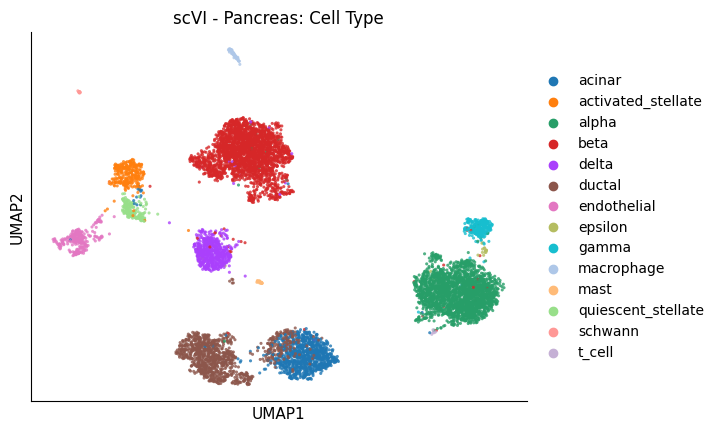

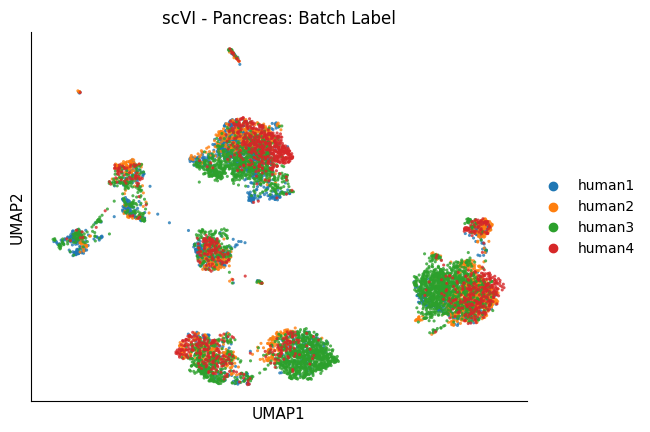

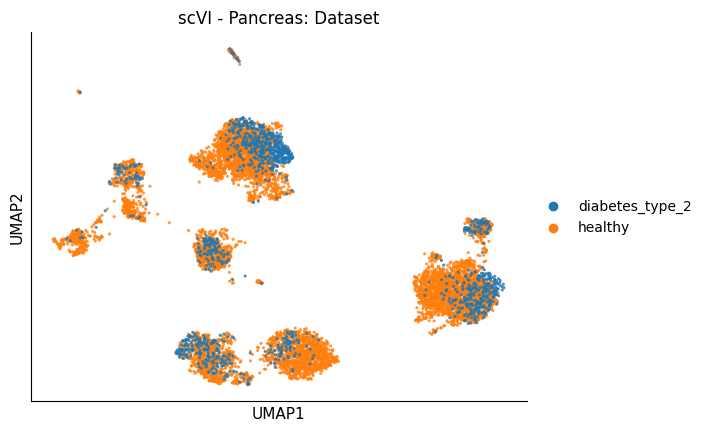

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
Accuracy: 0.9324635456638527
                    precision    recall  f1-score   support

            acinar       0.03      1.00      0.06         2
activated_stellate       0.96      0.96      0.96        52
             alpha       0.99      0.99      0.99       284
              beta       0.99      0.98      0.99       495
             delta       0.95      0.99      0.97       101
            ductal       1.00      0.75      0.85       280
       endothelial       0.88      1.00      0.93         7
           epsilon       1.00      1.00      1.00         1
             gamma       0.95      1.00      0.98        63
        macrophage       1.00      1.00      1.00        10
              mast       1.00      1.00      1.00         1
quiescent_stellate       0.75      0.60      0.67         5
           schwann       1.00      1.00      1.00         1
            t_cell       0.50      1.00      0.67         1

          accuracy                       

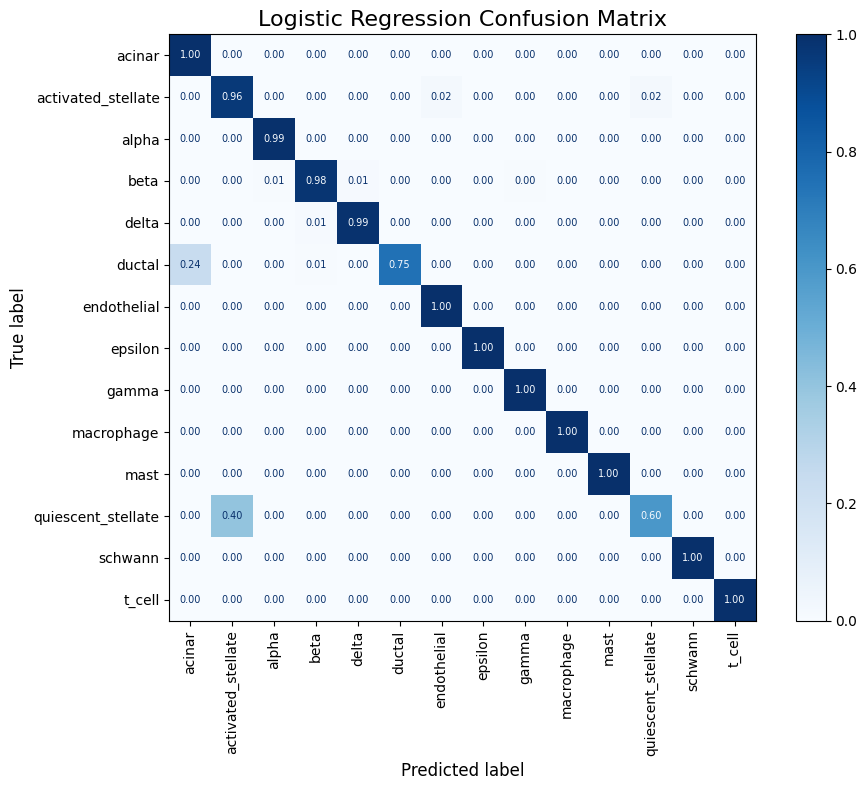


=== k-NN ===
Accuracy: 0.9447429009976976
                    precision    recall  f1-score   support

            acinar       0.04      1.00      0.07         2
activated_stellate       1.00      0.96      0.98        52
             alpha       0.98      0.99      0.99       284
              beta       1.00      0.98      0.99       495
             delta       0.97      0.98      0.98       101
            ductal       1.00      0.80      0.89       280
       endothelial       0.78      1.00      0.88         7
           epsilon       0.50      1.00      0.67         1
             gamma       0.94      1.00      0.97        63
        macrophage       1.00      1.00      1.00        10
              mast       0.33      1.00      0.50         1
quiescent_stellate       0.83      1.00      0.91         5
           schwann       1.00      1.00      1.00         1
            t_cell       1.00      1.00      1.00         1

          accuracy                           0.94      

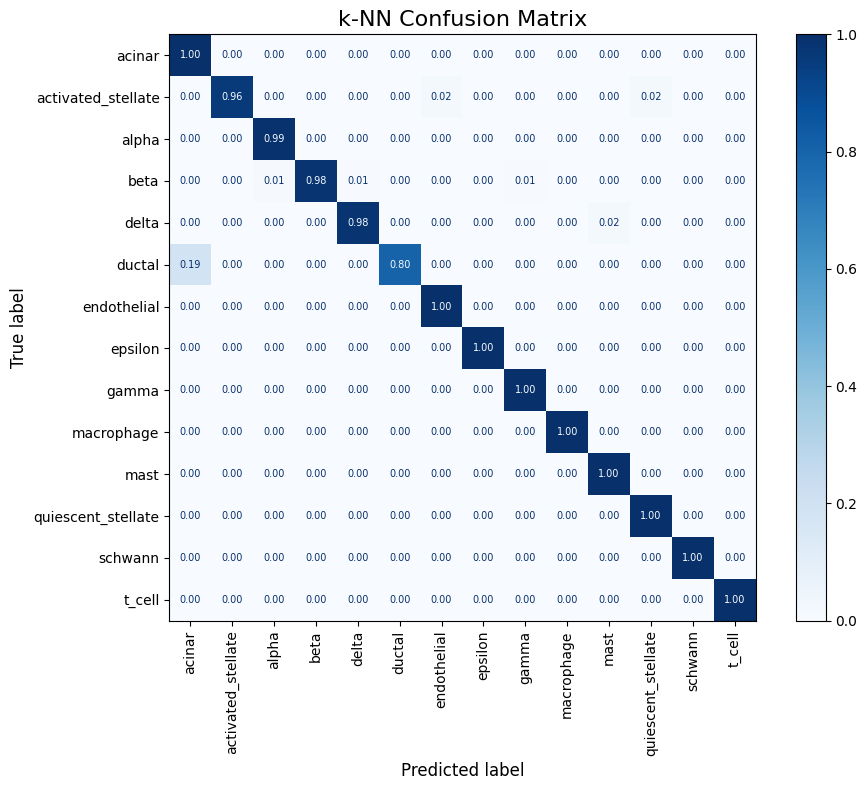

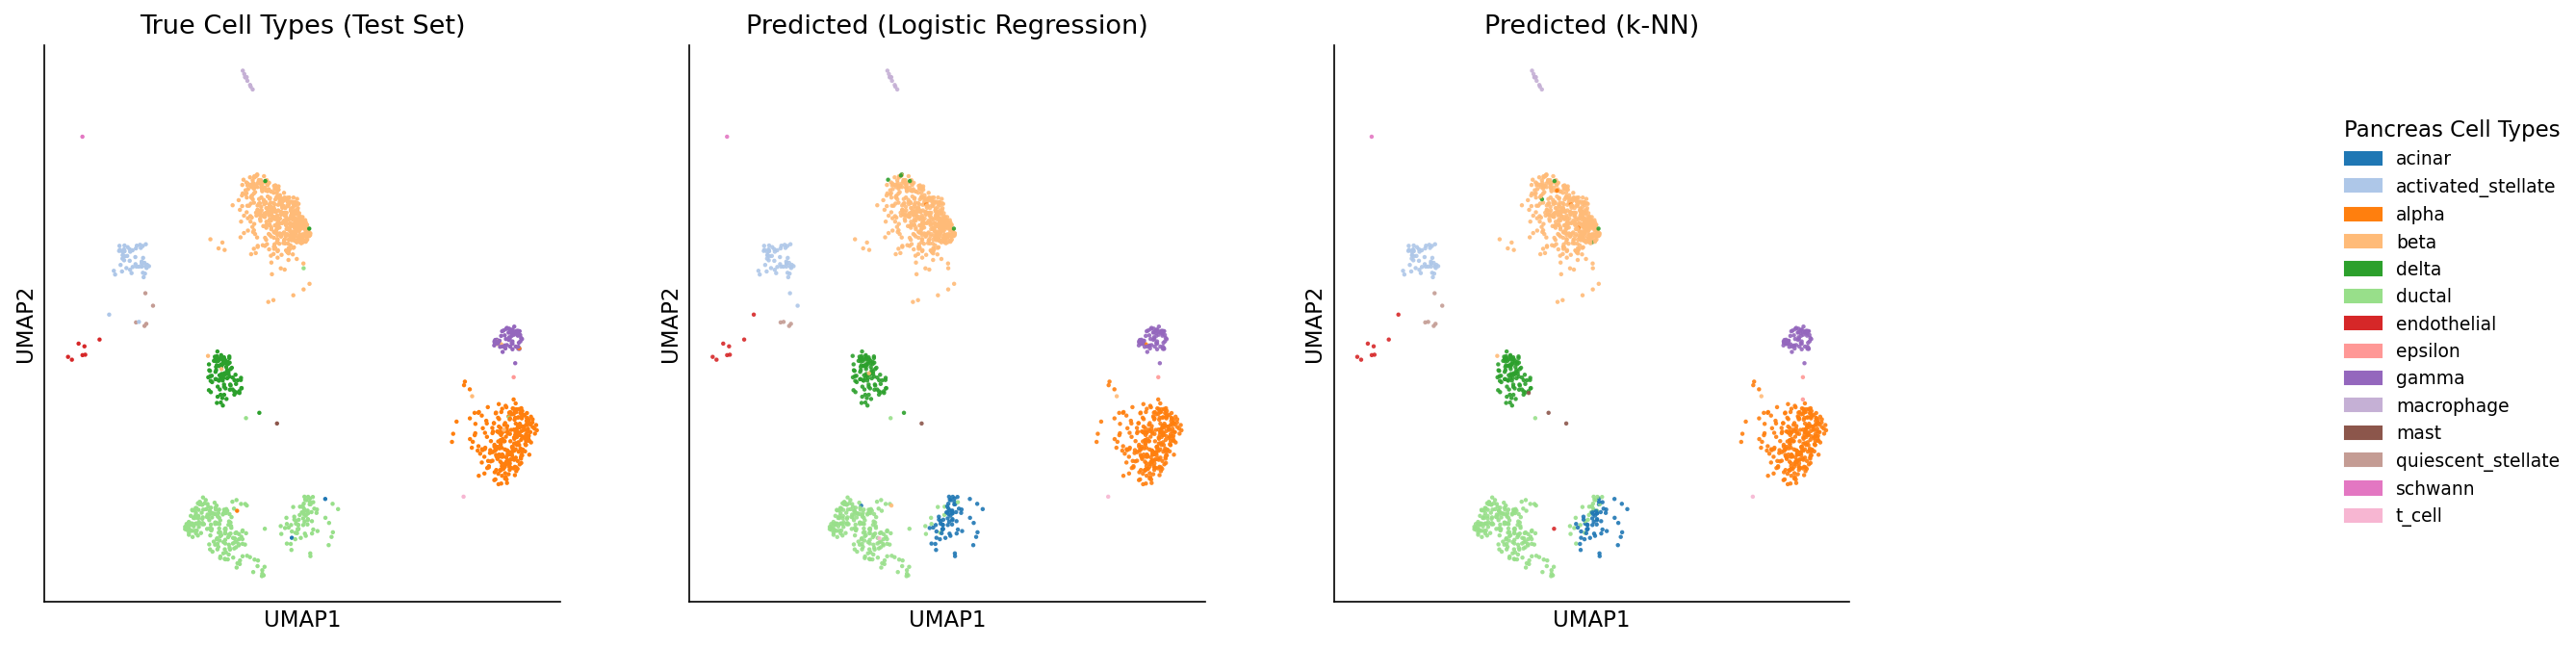

In [ ]:

## Visualization

sc.pp.neighbors(adata1, use_rep="X_scVI")
sc.tl.umap(adata1)

ax = sc.pl.umap(
    adata1,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Pancreas: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata1,
    color='donor_id',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Pancreas: Batch Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata1,
    color='disease',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Pancreas: Dataset"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier using Geneformer embeddings  3 batches for train and 1 for test

train_data = adata1[adata1.obs["disease"] == "healthy"].copy()
test_data = adata1[adata1.obs["disease"] == "diabetes_type_2"].copy()

X_train = train_data.obsm["X_scVI"]
X_test  = test_data.obsm["X_scVI"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

In [ ]:
label_keys = ["cell_type", "donor_id", "disease"]
# Compute scores
scores = compute_silhouette_and_lisi(adata, label_keys, embed_key="X_pca", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': np.float32(0.22400242), 'donor_id': np.float32(0.026016047), 'disease': np.float32(0.018741373)}
LISI Scores: {'cell_type': 1.0, 'donor_id': 1.0345481642019765, 'disease': 1.0018676979021157}
